# Part 1: Structured Data (Tabular Churn Prediction)

We predict customer churn using structured tabular features such as tenure, contract type, and monthly charges, and compare a classical model like logistic regression with deep learning models such as feedforward neural networks to evaluate whether increased model complexity improves churn prediction.

In [ ]:
import numpy as np
import random
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

import os

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

# ===============================
# Libraries
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    roc_curve
)
from sklearn.linear_model import LogisticRegression

KeyboardInterrupt: 

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

df.info()

df = df.drop(columns=["customerID"])

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Final data shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn distribution:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


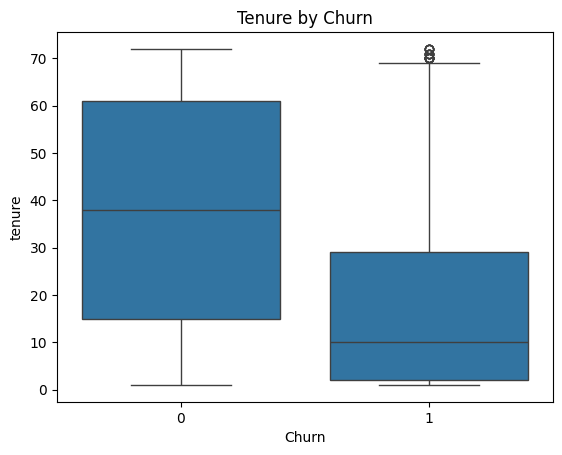

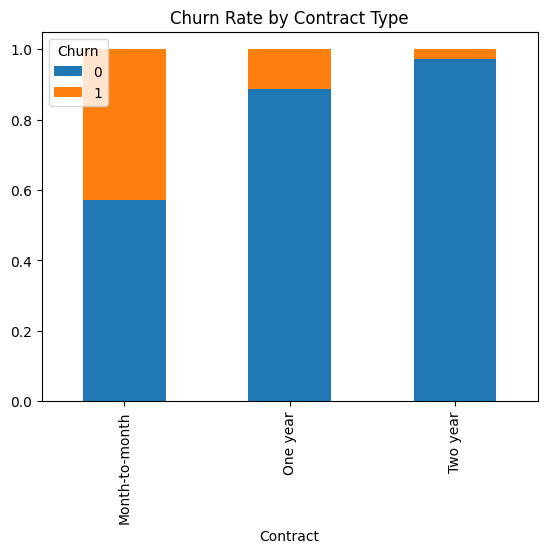

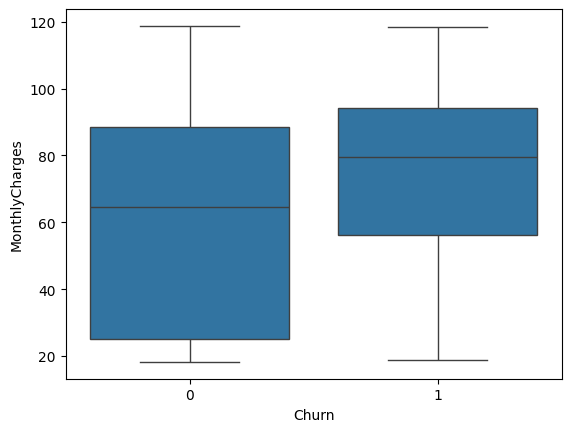

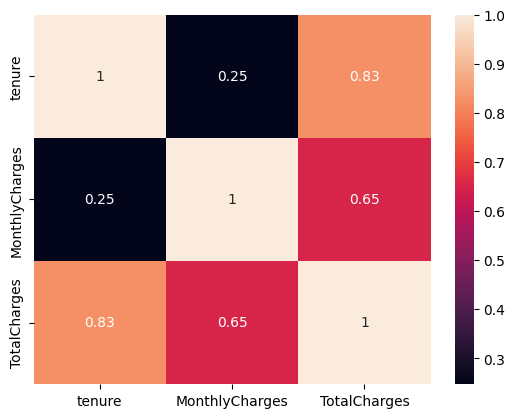

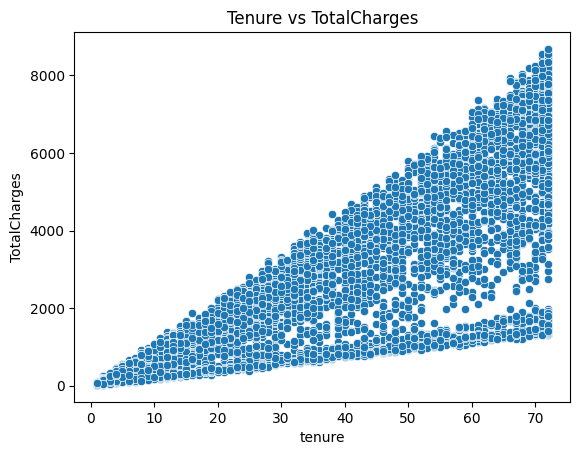

In [ ]:
print("Churn distribution:")
print(df["Churn"].value_counts(normalize=True))

# Tenure vs Churn
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure by Churn")
plt.show()

# Contract vs Churn
contract_churn = pd.crosstab(
    df["Contract"], df["Churn"], normalize="index"
)
contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Contract Type")
plt.show()

# MonthlyCharges vs Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

# Correlation
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.show()

sns.scatterplot(x="tenure", y="TotalCharges", data=df)
plt.title("Tenure vs TotalCharges")
plt.show()

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

feature_names = df_encoded.drop(columns=["Churn"]).columns.tolist()

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

print("Number of features:", len(feature_names))

Number of features: 30


In [ ]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)

print("Feature count check:",
      X_train.shape[1] == len(feature_names))

Feature count check: True


In [ ]:
log_base = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

log_base.fit(X_train, y_train)

y_prob_base = log_base.predict_proba(X_test)[:, 1]

print("Baseline AUC:",
      roc_auc_score(y_test, y_prob_base))

print(classification_report(
    y_test,
    log_base.predict(X_test)
))

Baseline AUC: 0.8356727976766699
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [ ]:
log_weight = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

log_weight.fit(X_train, y_train)

y_prob_weight = log_weight.predict_proba(X_test)[:, 1]

print("Weighted AUC:",
      roc_auc_score(y_test, y_prob_weight))

print(classification_report(
    y_test,
    log_weight.predict(X_test)
))

Weighted AUC: 0.8349765233911922
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [ ]:
X_reduced = X.drop(columns=["TotalCharges"])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

log_reduced = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

log_reduced.fit(X_train_r, y_train_r)

print("Reduced AUC:",
      roc_auc_score(
          y_test_r,
          log_reduced.predict_proba(X_test_r)[:, 1]
      ))

Reduced AUC: 0.8333173716551656


In [ ]:
log_both = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

log_both.fit(X_train_r, y_train_r)

print("Weighted + Reduced AUC:",
      roc_auc_score(
          y_test_r,
          log_both.predict_proba(X_test_r)[:, 1]
      ))

Weighted + Reduced AUC: 0.8327556931423454


Threshold=0.3
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



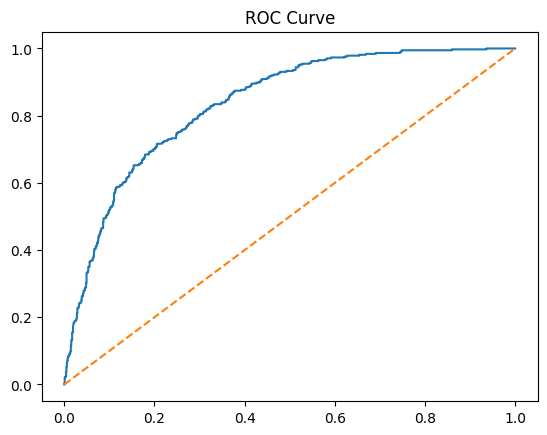

In [ ]:
threshold = 0.3
y_pred_thresh = (y_prob_base >= threshold).astype(int)

print("Threshold=0.3")
print(classification_report(y_test, y_pred_thresh))

fpr, tpr, _ = roc_curve(y_test, y_prob_base)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.show()

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ===============================
# Best Model Tracker
# ===============================
best_model = None
best_model_name = None
best_auc = 0

In [ ]:
def build_basic(lr=0.001):
    model = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

basic_model = build_basic()

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

basic_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
    shuffle=False
)

print("Basic MLP AUC:",
      basic_model.evaluate(X_test, y_test, verbose=0)[1])

basic_auc = basic_model.evaluate(X_test, y_test, verbose=0)[1]

if basic_auc > best_auc:
    best_auc = basic_auc
    best_model = basic_model
    best_model_name = "Basic MLP"
print("Current Best Model:",best_model_name)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.7207 - loss: 0.5170 - val_auc: 0.8151 - val_loss: 0.4478
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8345 - loss: 0.4235 - val_auc: 0.8241 - val_loss: 0.4387
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8423 - loss: 0.4146 - val_auc: 0.8263 - val_loss: 0.4357
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8463 - loss: 0.4099 - val_auc: 0.8279 - val_loss: 0.4344
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8492 - loss: 0.4069 - val_auc: 0.8280 - val_loss: 0.4340
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8516 - loss: 0.4044 - val_auc: 0.8280 - val_loss: 0.4339
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8535 - loss: 0.4020 - val_auc: 0.8275 - val_loss: 0.4345
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8554 - loss: 0.4000 - val_auc: 0.8275 - val_loss: 0.4348
Epoch 9/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - au

In [ ]:
lrs = [0.01, 0.005, 0.001, 0.0005,0.0004, 0.0003,0.0002, 0.0001]

for lr in lrs:
    model = build_basic(lr)
    model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
        shuffle=False
    )
    auc_value = model.evaluate(X_test, y_test, verbose=0)[1]

    print("lr:", lr, "AUC:", auc_value)

    if auc_value > best_auc:
        best_auc = auc_value
        best_model = model
        best_model_name = f"Basic MLP (lr={lr})"
print("Current Best Model:",best_model_name)


lr: 0.01 AUC: 0.8262588977813721
lr: 0.005 AUC: 0.8298049569129944
lr: 0.001 AUC: 0.8301504850387573
lr: 0.0005 AUC: 0.8238205909729004
lr: 0.0004 AUC: 0.8304377794265747
lr: 0.0003 AUC: 0.834531307220459
lr: 0.0002 AUC: 0.832903265953064
lr: 0.0001 AUC: 0.8332966566085815
Current Best Model: Basic MLP (lr=0.0003)


In [ ]:
dropout_rates = [0.2, 0.3, 0.4, 0.5, 0.6]

for rate in dropout_rates:
    model = build_regularized(
        lr=0.0003,
        drop_rate=rate
    )
    model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
        shuffle=False
    )

    auc_value = model.evaluate(X_test, y_test, verbose=0)[1]

    print("Dropout:", rate, "AUC:", auc_value)

    if auc_value > best_auc:
        best_auc = auc_value
        best_model = model
        best_model_name = f"Regularized MLP (dropout={rate})"
print("Current Best Model:",best_model_name)

Dropout: 0.2 AUC: 0.8307833671569824
Dropout: 0.3 AUC: 0.8370445966720581
Dropout: 0.4 AUC: 0.8347150683403015
Dropout: 0.5 AUC: 0.8319364786148071
Dropout: 0.6 AUC: 0.8331853747367859
Current Best Model: Regularized MLP (dropout=0.3)


In [ ]:
def build_deep(lr=0.0003):
    model = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

deep_model = build_deep()

deep_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
    shuffle=False
)

print("Deep Model AUC:",
      deep_model.evaluate(X_test, y_test, verbose=0)[1])

deep_auc = deep_model.evaluate(X_test, y_test, verbose=0)[1]

if deep_auc > best_auc:
    best_auc = deep_auc
    best_model = deep_model
    best_model_name = "Deep MLP"
print("Current Best Model:",best_model_name)

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.7364 - loss: 0.5071 - val_auc: 0.8135 - val_loss: 0.4517
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8302 - loss: 0.4328 - val_auc: 0.8234 - val_loss: 0.4403
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8369 - loss: 0.4226 - val_auc: 0.8262 - val_loss: 0.4365
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8419 - loss: 0.4166 - val_auc: 0.8278 - val_loss: 0.4348
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8454 - loss: 0.4123 - val_auc: 0.8285 - val_loss: 0.4340
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.8484 - loss: 0.4088 - val_auc: 0.8288 - val_loss: 0.4335
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.8507 - loss: 0.4059 - val_auc: 0.8288 - val_loss: 0.4337
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.8530 - loss: 0.4034 - val_auc: 0.8289 - val_loss: 0.4339
Epoch 9/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/

In [ ]:
from tensorflow.keras import regularizers

def build_regularized(lr=0.0003, drop_rate=0.3):
    model = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation="relu",
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(drop_rate, seed=SEED),
        layers.Dense(16, activation="relu",
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(drop_rate, seed=SEED),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

reg_model = build_regularized()

reg_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
    shuffle=False
)

print("Regularized MLP AUC:",
      reg_model.evaluate(X_test, y_test, verbose=0)[1])

reg_auc = reg_model.evaluate(X_test, y_test, verbose=0)[1]

if reg_auc > best_auc:
    best_auc = reg_auc
    best_model = reg_model
    best_model_name = "Regularized MLP"
print("Current Best Model:",best_model_name)

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.5584 - loss: 0.7026 - val_auc: 0.7629 - val_loss: 0.5512
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7033 - loss: 0.5860 - val_auc: 0.7929 - val_loss: 0.5238
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7608 - loss: 0.5473 - val_auc: 0.8061 - val_loss: 0.5105
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7622 - loss: 0.5464 - val_auc: 0.8144 - val_loss: 0.5017
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7894 - loss: 0.5235 - val_auc: 0.8181 - val_loss: 0.4966
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7997 - loss: 0.5085 - val_auc: 0.8204 - val_loss: 0.4919
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8068 - loss: 0.5034 - val_auc: 0.8225 - val_loss: 0.4886
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8182 - loss: 0.4920 - val_auc: 0.8254 - val_loss: 0.4846
Epoch 9/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

Best model selected: Regularized MLP (dropout=0.3)
Best AUC: 0.8370445966720581


  0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipython-input-352/1820311278.py:39: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


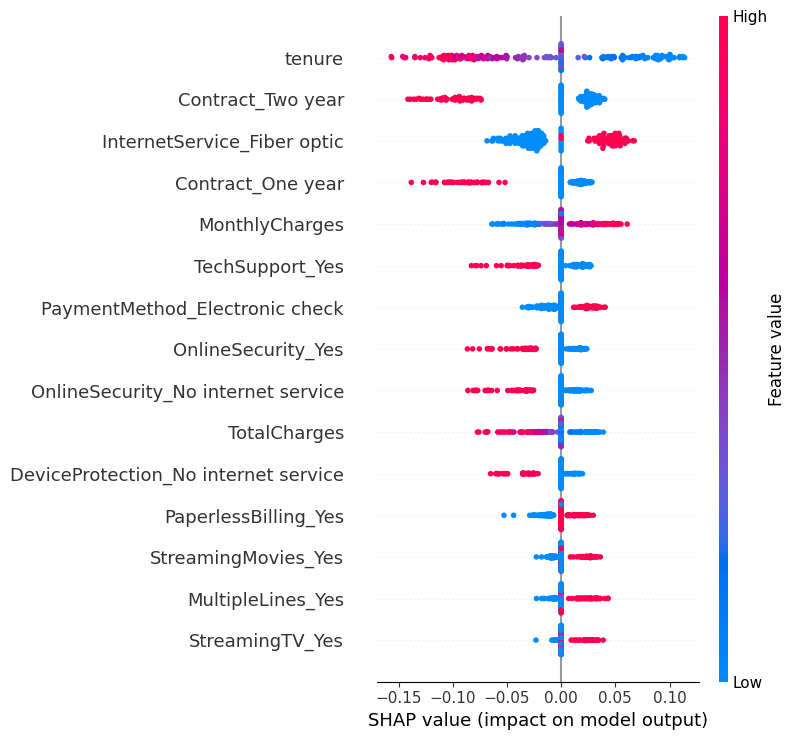

In [ ]:
import shap

np.random.seed(SEED)

print("Best model selected:", best_model_name)
print("Best AUC:", best_auc)

def predict_fn(X):
    return best_model.predict(X, verbose=0).flatten()

background_size = 100
sample_size = 200

idx_background = np.random.choice(
    X_train.shape[0],
    background_size,
    replace=False
)

X_background = X_train[idx_background]
X_sample = X_test[:sample_size]

X_sample_df = pd.DataFrame(
    X_sample,
    columns=feature_names
)

explainer = shap.KernelExplainer(
    predict_fn,
    X_background
)

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

plt.figure(figsize=(8,6))
shap.summary_plot(
    shap_values,
    X_sample_df,
    max_display=15,
    show=False
)
plt.show()

## Part 2: NLP analysis of reviews

We analyze customer reviews as unstructured text data. We first use sentiment as a proxy for churn likelihood, then classify complaint categories to identify the likely reason for dissatisfaction.

In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

df = pd.read_csv('mint_mobile_reviews_classified.csv')
df = df[['text', 'rating', 'sentiment', 'complaint_category']].copy()

print(df.shape)
display(df.head())

print(df['sentiment'].value_counts(dropna=False))
print(df['complaint_category'].value_counts(dropna=False))

(5521, 4)


,text,rating,sentiment,complaint_category
0,Worst company ever. Bought the 3 month entry s...,1,Negative,Network & Coverage
1,Awful. Absolutely AWFUL customer service. The ...,2,Negative,Number Porting & Account Setup
2,Customer for 2 years. Pre paid both years. Nev...,1,Negative,Data Speed & Performance
3,I ve been a Mint Mobile customer since around ...,1,Negative,Billing & Pricing
4,I believe you are in error to say I have 5gb o...,1,Negative,Data Speed & Performance


sentiment
Negative    3244
Positive    2277
Name: count, dtype: int64
complaint_category
NaN                                  2277
Customer Service                     1053
Billing & Pricing                     675
Number Porting & Account Setup        470
Network & Coverage                    430
Uncategorized                         304
Data Speed & Performance              224
App, Website & Account Management      88
Name: count, dtype: int64


Using sentiment from rating as a proxy for churn likelihood because negative reviews indicate dissatisfied customers who are likely to churn. We label customers who are likely to churn as 1 and those who are satisfied and unlikely to churn as 0.

In [ ]:
# Create the 'label' column based on 'sentiment'
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'Negative' else (0 if x == 'Positive' else None))

display(df.head())

,text,rating,sentiment,complaint_category,label
0,Worst company ever. Bought the 3 month entry s...,1,Negative,Network & Coverage,1
1,Awful. Absolutely AWFUL customer service. The ...,2,Negative,Number Porting & Account Setup,1
2,Customer for 2 years. Pre paid both years. Nev...,1,Negative,Data Speed & Performance,1
3,I ve been a Mint Mobile customer since around ...,1,Negative,Billing & Pricing,1
4,I believe you are in error to say I have 5gb o...,1,Negative,Data Speed & Performance,1


In [ ]:
test_val_df = df.sample(frac=0.5, random_state=42)
train_df = df.drop(test_val_df.index)

val_df = test_val_df.sample(frac=0.5, random_state=43)
test_df = test_val_df.drop(val_df.index)

# Get the labels for the train/test/validation sets
y_train = train_df['label'].to_numpy().astype(np.float32)
y_test = test_df['label'].to_numpy().astype(np.float32)
y_val = val_df['label'].to_numpy().astype(np.float32)

print(f'Train set shape: {train_df.shape}')
print(f'Test set shape: {test_df.shape}')
print(f'Validation set shape: {val_df.shape}')

Train set shape: (2761, 5)
Test set shape: (1380, 5)
Validation set shape: (1380, 5)


We are applying the Bag-Of-Words method for converting every review into a numerical representation (vector) that can be passed throught a neural network. Then, we will create a neural network to classify the articles into `likely to churn` or `not likely to churn`.

We will begin by applying the STIE process (standardize, tokenize, index, encode) into our articles.

In [ ]:
max_tokens = 5000 # size of vocabulary space
text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    standardize='lower_and_strip_punctuation', # default
    split='whitespace', # default
    output_mode="multi_hot",
)

text_vectorization.adapt(train_df['text'])
text_vectorization.get_vocabulary()[:20]

#apply function to get multihot encodings
X_train = text_vectorization(train_df['text'])
X_val = text_vectorization(val_df['text'])
X_test = text_vectorization(test_df['text'])

pd.DataFrame(X_train, columns=text_vectorization.get_vocabulary()).astype(int)

inputs = keras.layers.Input(shape=(max_tokens, ), name='input')
x = keras.layers.Dense(128, activation="relu", name='hidden')(inputs)
outputs = keras.layers.Dense(1, activation="sigmoid", name='output')(x)
bow_model = keras.Model(inputs, outputs, name='simple_bow')

bow_model.summary()

bow_model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Train the model on the training set
bow_model.fit(x=X_train, y=y_train,
          validation_data=(X_val, y_val),
          epochs=10,
          batch_size=32)

print('Test Accuracy is', bow_model.evaluate(X_test, y_test)[1])

Model: "simple_bow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,257 (2.44 MB)

 Trainable params: 640,257 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8261 - loss: 0.4022 - val_accuracy: 0.8681 - val_loss: 0.2988
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9301 - loss: 0.1876 - val_accuracy: 0.8928 - val_loss: 0.2528
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9631 - loss: 0.1123 - val_accuracy: 0.9094 - val_loss: 0.2714
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9775 - loss: 0.0749 - val_accuracy: 0.9058 - val_loss: 0.2959
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9862 - loss: 0.0527 - val_accuracy: 0.9029 - val_loss: 0.3225
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9909 - loss: 0.0392 - val_accuracy: 0.8993 - val_loss: 0.3370
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9924 - loss: 0.0305 - val_accuracy: 0.8971 - val_loss: 0.3632
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9931 - loss: 0.0252 - val_accuracy: 0.8971 - val_loss

Simple Bag of Words model Test Accuracy is 86.96%. We next strengthen the bag-of-words baseline by using count encoding with bigrams, allowing the model to capture both word frequency and short phrases rather than only single-word presence.

In [ ]:
max_tokens = 20000

text_vectorization_count = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    ngrams=2,
    output_mode='count'
)

text_vectorization_count.adapt(train_df['text'])

X_train_count = text_vectorization_count(train_df['text'])
X_val_count = text_vectorization_count(val_df['text'])
X_test_count = text_vectorization_count(test_df['text'])

inputs = keras.layers.Input(shape=(max_tokens,), name='input')
x = keras.layers.Dense(128, activation='relu')(inputs)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

bow_count_model = keras.Model(inputs, outputs, name='sentiment_bow_count_bigram')

bow_count_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_bow_count = bow_count_model.fit(
    x=X_train_count,
    y=y_train,
    validation_data=(X_val_count, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )],
    verbose=1
)

print('Sentiment BoW Count+Bigram Test Accuracy:',
      bow_count_model.evaluate(X_test_count, y_test, verbose=0)[1])

Epoch 1/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8214 - loss: 0.4087 - val_accuracy: 0.8152 - val_loss: 0.4382
Epoch 2/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9478 - loss: 0.1461 - val_accuracy: 0.8870 - val_loss: 0.2856
Epoch 3/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9757 - loss: 0.0691 - val_accuracy: 0.9116 - val_loss: 0.3296
Epoch 4/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9888 - loss: 0.0297 - val_accuracy: 0.9080 - val_loss: 0.3187
Epoch 5/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9913 - loss: 0.0181 - val_accuracy: 0.9022 - val_loss: 0.3623
Sentiment BoW Count+Bigram Test Accuracy: 0.8949275612831116


The improved bag-of-words model achieved a test accuracy of 89.49, outperforming the simpler unigram baseline. Finally, we evaluate a pretrained BERT-based model to test whether a transformer architecture can better capture semantic context in customer reviews than bag-of-words representations.

In [ ]:
import tensorflow as tf
import keras_hub

tf.config.optimizer.set_jit(False)

preprocessor = keras_hub.models.BertPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=128
)

backbone = keras_hub.models.BertBackbone.from_preset(
    "bert_base_en_uncased"
)

text_input = keras.Input(shape=(), dtype=tf.string, name="text")
x = preprocessor(text_input)
x = backbone(x)["pooled_output"]
x = keras.layers.Dropout(0.2)(x)
output = keras.layers.Dense(1, activation="sigmoid")(x)

bert_sentiment_model = keras.Model(text_input, output)

bert_sentiment_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
    jit_compile=False
)

x_train_text = train_df['text'].fillna('').astype(str).to_numpy()
x_val_text = val_df['text'].fillna('').astype(str).to_numpy()
x_test_text = test_df['text'].fillna('').astype(str).to_numpy()

history_bert_sentiment = bert_sentiment_model.fit(
    x=x_train_text,
    y=y_train.astype("float32"),
    validation_data=(x_val_text, y_val.astype("float32")),
    epochs=3,
    batch_size=4,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=1,
        restore_best_weights=True
    )],
    verbose=1
)

print(
    "Sentiment BERT Test Accuracy:",
    bert_sentiment_model.evaluate(x_test_text, y_test.astype("float32"), verbose=0)[1]
)

100%|██████████| 457/457 [00:00<00:00, 876kB/s]


Epoch 1/3
691/691 ━━━━━━━━━━━━━━━━━━━━ 188s 221ms/step - accuracy: 0.8968 - loss: 0.2675 - val_accuracy: 0.9377 - val_loss: 0.1502
Epoch 2/3
691/691 ━━━━━━━━━━━━━━━━━━━━ 149s 216ms/step - accuracy: 0.9591 - loss: 0.1212 - val_accuracy: 0.9312 - val_loss: 0.2027
Sentiment BERT Test Accuracy: 0.9123188257217407


The BERT-based model achieved a test accuracy of 0.9123, outperforming both bag-of-words baselines. This suggests that contextual language representations provide additional value for text-based churn-signal detection.

**Sentiment Classification Summary**

- Simple BoW accuracy: 0.8696
- BoW with count + bigrams accuracy: 0.8950
- BERT accuracy: 0.9123

As text models become more expressive, performance improves. Unlike the tabular churn task, the text-based sentiment task benefits more clearly from deep learning.

## Identifying complaint reason category for negative reviews
We next classify the underlying reason for dissatisfaction from review text. This is a multiclass NLP task with six complaint categories: Network & Coverage, Number Porting & Account Setup, Data Speed & Performance, Billing & Pricing, Customer Service, and App, Website & Account Management. Because the categories are imbalanced, we evaluate performance using both accuracy and macro F1.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
import numpy as np

# Complaint-category dataset
df_categories = df[['text', 'complaint_category']].copy()
df_categories = df_categories.dropna()
df_categories = df_categories[df_categories['complaint_category'] != 'Uncategorized'].copy()

# Encode labels
label_encoder = LabelEncoder()
df_categories['category_label'] = label_encoder.fit_transform(df_categories['complaint_category'])

num_classes = len(label_encoder.classes_)
print("Number of unique complaint categories:", num_classes)
print("Original categories:", list(label_encoder.classes_))

# Stratified split: 70/15/15
train_df_cat, temp_df_cat = train_test_split(
    df_categories,
    test_size=0.30,
    random_state=42,
    stratify=df_categories['category_label']
)

val_df_cat, test_df_cat = train_test_split(
    temp_df_cat,
    test_size=0.50,
    random_state=43,
    stratify=temp_df_cat['category_label']
)

y_train_cat = train_df_cat['category_label'].to_numpy().astype(np.int32)
y_val_cat = val_df_cat['category_label'].to_numpy().astype(np.int32)
y_test_cat = test_df_cat['category_label'].to_numpy().astype(np.int32)

print(f"Train set shape: {train_df_cat.shape}")
print(f"Validation set shape: {val_df_cat.shape}")
print(f"Test set shape: {test_df_cat.shape}")

display(train_df_cat.head())

Number of unique complaint categories: 6
Original categories: ['App, Website & Account Management', 'Billing & Pricing', 'Customer Service', 'Data Speed & Performance', 'Network & Coverage', 'Number Porting & Account Setup']
Train set shape: (2058, 3)
Validation set shape: (441, 3)
Test set shape: (441, 3)


,text,complaint_category,category_label
5205,"The price is attractive. However, every few da...",Customer Service,2
1504,Mint Mobile sent an email for those affected b...,Customer Service,2
1010,I paid for mint mobile service a year at a tim...,Billing & Pricing,1
4216,Total scammers!! I purchased international roa...,Network & Coverage,4
3797,I have just experienced the worst customer ser...,Billing & Pricing,1


In [ ]:
max_tokens_cat = 20000

text_vectorization_cat = keras.layers.TextVectorization(
    max_tokens=max_tokens_cat,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    ngrams=2,
    output_mode='count'
)

text_vectorization_cat.adapt(train_df_cat['text'])

X_train_cat = text_vectorization_cat(train_df_cat['text'])
X_val_cat = text_vectorization_cat(val_df_cat['text'])
X_test_cat = text_vectorization_cat(test_df_cat['text'])

inputs_cat = keras.layers.Input(shape=(max_tokens_cat,), name='input_category')
x_cat = keras.layers.Dense(128, activation='relu', name='hidden_1_cat')(inputs_cat)
x_cat = keras.layers.Dropout(0.3)(x_cat)
x_cat = keras.layers.Dense(64, activation='relu', name='hidden_2_cat')(x_cat)
outputs_cat = keras.layers.Dense(num_classes, activation='softmax', name='output_category')(x_cat)

bow_model_cat = keras.Model(inputs_cat, outputs_cat, name='complaint_category_bow')

bow_model_cat.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cat = bow_model_cat.fit(
    X_train_cat,
    y_train_cat,
    validation_data=(X_val_cat, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )],
    verbose=1
)

test_probs_cat = bow_model_cat.predict(X_test_cat)
test_pred_cat = np.argmax(test_probs_cat, axis=1)

print("Complaint Category BoW Accuracy:",
      bow_model_cat.evaluate(X_test_cat, y_test_cat, verbose=0)[1])
print("Complaint Category BoW Macro F1:",
      f1_score(y_test_cat, test_pred_cat, average='macro'))
print(classification_report(
    y_test_cat,
    test_pred_cat,
    target_names=label_encoder.classes_
))

Epoch 1/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.4252 - loss: 1.5176 - val_accuracy: 0.6281 - val_loss: 1.2492
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7604 - loss: 0.8366 - val_accuracy: 0.6508 - val_loss: 1.0675
Epoch 3/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9407 - loss: 0.3020 - val_accuracy: 0.6803 - val_loss: 1.0548
Epoch 4/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9810 - loss: 0.1240 - val_accuracy: 0.6327 - val_loss: 1.4235
Epoch 5/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9903 - loss: 0.0744 - val_accuracy: 0.6621 - val_loss: 1.3711
Epoch 6/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9917 - loss: 0.0508 - val_accuracy: 0.5873 - val_loss: 2.0649
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Complaint Category BoW Accuracy: 0.6893423795700073
Complaint Category BoW Macro F1: 0.6027028405631124
                                   precision    recall  f1-score   support

App, Website & Account 

The bag-of-words complaint-category model achieved a test accuracy of 0.6893 and a macro F1 score of 0.6027. Performance is strongest on larger categories such as Customer Service and Network & Coverage, while weaker on smaller classes such as App, Website & Account Management.

We then test a BERT-based classifier to evaluate whether contextual language representations improve complaint-category prediction relative to the bag-of-words baseline.

In [ ]:
import tensorflow as tf
import keras
import keras_hub
import numpy as np
from sklearn.metrics import classification_report, f1_score

tf.config.optimizer.set_jit(False)

# Clean text + labels
x_train_cat_text = train_df_cat['text'].fillna('').astype(str).to_numpy()
x_val_cat_text = val_df_cat['text'].fillna('').astype(str).to_numpy()
x_test_cat_text = test_df_cat['text'].fillna('').astype(str).to_numpy()

y_train_cat = np.array(y_train_cat).astype("int32")
y_val_cat = np.array(y_val_cat).astype("int32")
y_test_cat = np.array(y_test_cat).astype("int32")

preprocessor_cat = keras_hub.models.BertPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=128
)

backbone_cat = keras_hub.models.BertBackbone.from_preset(
    "bert_base_en_uncased"
)

text_input_cat = keras.Input(shape=(), dtype=tf.string, name="text")
x_cat = preprocessor_cat(text_input_cat)
x_cat = backbone_cat(x_cat)["pooled_output"]
x_cat = keras.layers.Dropout(0.3)(x_cat)
output_cat = keras.layers.Dense(num_classes, activation="softmax")(x_cat)

bert_cat_model = keras.Model(text_input_cat, output_cat, name="complaint_category_bert")

bert_cat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)

history_bert_cat = bert_cat_model.fit(
    x=x_train_cat_text,
    y=y_train_cat,
    validation_data=(x_val_cat_text, y_val_cat),
    epochs=4,
    batch_size=4,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=1,
        restore_best_weights=True
    )],
    verbose=1
)

bert_cat_probs = bert_cat_model.predict(x_test_cat_text)
bert_cat_pred = np.argmax(bert_cat_probs, axis=1)

print("Complaint Category BERT Accuracy:",
      bert_cat_model.evaluate(x_test_cat_text, y_test_cat, verbose=0)[1])
print("Complaint Category BERT Macro F1:",
      f1_score(y_test_cat, bert_cat_pred, average='macro'))
print(classification_report(
    y_test_cat,
    bert_cat_pred,
    target_names=label_encoder.classes_
))


Epoch 1/4
515/515 ━━━━━━━━━━━━━━━━━━━━ 143s 212ms/step - accuracy: 0.4704 - loss: 1.3629 - val_accuracy: 0.6417 - val_loss: 0.9924
Epoch 2/4
515/515 ━━━━━━━━━━━━━━━━━━━━ 104s 203ms/step - accuracy: 0.6793 - loss: 0.8781 - val_accuracy: 0.6871 - val_loss: 0.9120
Epoch 3/4
515/515 ━━━━━━━━━━━━━━━━━━━━ 104s 202ms/step - accuracy: 0.8071 - loss: 0.5574 - val_accuracy: 0.6939 - val_loss: 0.9937
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 514ms/step
Complaint Category BERT Accuracy: 0.6938775777816772
Complaint Category BERT Macro F1: 0.6241299331202336
                                   precision    recall  f1-score   support

App, Website & Account Management       0.50      0.15      0.24        13
                Billing & Pricing       0.65      0.81      0.72       102
                 Customer Service       0.82      0.64      0.72       158
         Data Speed & Performance       0.69      0.73      0.71        33
               Network & Coverage       0.78      0.73      0.76        64
   Numbe

The BERT complaint-category model achieved a test accuracy of 0.6939 and a macro F1 score of 0.6241. While the gain in accuracy is modest, the improvement in macro F1 indicates somewhat better performance across imbalanced classes.

**Complaint Category Classification Summary**

- BoW accuracy: 0.6893
- BoW macro F1: 0.6027
- BERT accuracy: 0.6939
- BERT macro F1: 0.6241

BERT provides only a small improvement in accuracy, but a more meaningful improvement in macro F1, suggesting better balanced performance across categories.

In the original tabular churn prediction task, deep learning provided little advantage over logistic regression. In contrast, for the text-based review tasks, model performance improved as the NLP approach became more expressive: from simple bag-of-words, to count + bigrams, to BERT. This suggests that deep learning is more useful for unstructured text data than for relatively simple structured tabular churn prediction.